# 03 · Feature Engineering

**Goal:** turn raw route columns into smarter, model-ready inputs — and prove each new
feature actually carries signal before we hand it to a model.

The reusable logic lives in `src/preprocessing.py` (so training code and a future
Databricks job can import the exact same definitions). This notebook *demonstrates and
validates* it.

New features we create:

| Feature | Idea |
|---|---|
| `cases_per_stop`, `miles_per_stop`, `weight_per_case` | route *intensity*, not just totals |
| `is_new_driver` | tenure < 90 days |
| `high_complexity_route` | many stops **and** high volume |
| `load_delay_over_30` | the 4.8x warehouse-delay flag, as a feature |
| `is_high_traffic`, `restaurant_heavy` | operational risk flags |
| `complexity_index` | stops × traffic interaction |
| `window_pressure_ord`, `start_delay_bucket` | ordered categoricals as ordinal codes |


## 1 · Setup

In [19]:
import sys, os
for p in ['../src', 'src', os.path.join(os.getcwd(), 'src')]:
    if os.path.isdir(p) and p not in sys.path:
        sys.path.insert(0, p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import data_generation as dg
import preprocessing as pp

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (9, 5)
pd.set_option('display.max_columns', 80)

df = dg.generate()
print("raw shape:", df.shape)

raw shape: (12000, 31)


## 2 · Apply feature engineering and inspect the new columns

In [20]:
feat = pp.engineer_features(df)

new_cols = pp.ENGINEERED_FEATURES
print("Added", len(new_cols), "engineered features:\n", new_cols)
feat[['planned_stops', 'planned_cases', 'planned_miles',
      'cases_per_stop', 'miles_per_stop',
      'is_new_driver', 'high_complexity_route',
      'complexity_index', 'start_delay_bucket']].head()

Added 11 engineered features:
 ['cases_per_stop', 'miles_per_stop', 'weight_per_case', 'is_new_driver', 'high_complexity_route', 'load_delay_over_30', 'is_high_traffic', 'restaurant_heavy', 'complexity_index', 'window_pressure_ord', 'start_delay_bucket']


,planned_stops,planned_cases,planned_miles,cases_per_stop,miles_per_stop,is_new_driver,high_complexity_route,complexity_index,start_delay_bucket
0,8,362,224,45.250000,28.000000,0,0,2.80,1
1,30,1167,33,38.900000,1.100000,0,1,16.50,1
2,12,494,177,41.166667,14.750000,0,0,6.36,0
3,30,929,145,30.966667,4.833333,0,1,19.20,1
4,30,1066,20,35.533333,0.666667,0,1,19.20,0


## 3 · Validate: do the new features separate delayed from on-time?

Same `delay_rate_by` idea as the EDA notebook. If an engineered feature is worth keeping,
its buckets should show a clear gradient in delay rate.


In [21]:
def delay_rate_by(data, col, bins=None, labels=None, order=None, title=None):
    d = data.copy()
    d['_grp'] = pd.cut(d[col], bins=bins, labels=labels) if bins is not None else d[col]
    rate = d.groupby('_grp', observed=True)['is_delayed'].mean()
    if order is not None:
        rate = rate.reindex(order)
    ax = rate.plot(kind='bar', color=sns.color_palette('flare', len(rate)))
    ax.set_ylabel('delay rate'); ax.set_xlabel(col)
    ax.set_title(title or f'Delay rate by {col}')
    ax.set_ylim(0, min(1, rate.max() * 1.25))
    for i, v in enumerate(rate.values):
        ax.text(i, v + 0.01, f'{v:.0%}', ha='center', fontsize=9)
    plt.xticks(rotation=0); plt.tight_layout(); plt.show()
    return rate

### 3a · `cases_per_stop` — route intensity

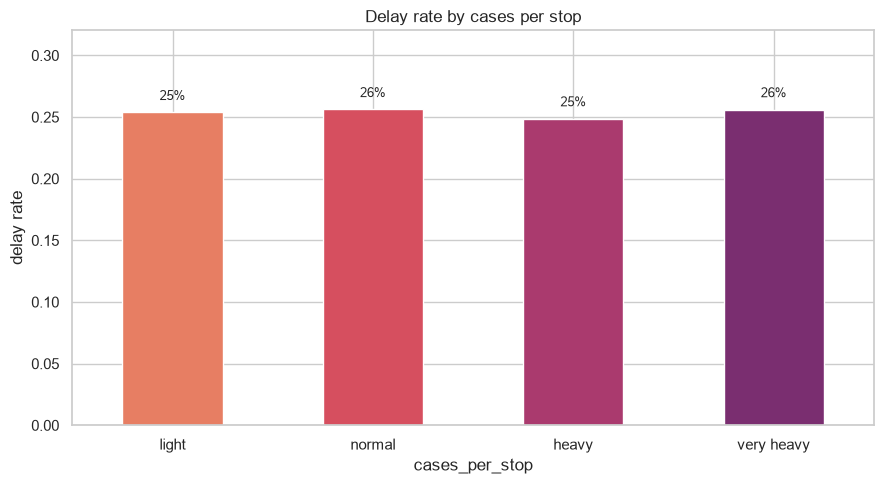

_grp
light         0.253778
normal        0.256164
heavy         0.248693
very heavy    0.256048
Name: is_delayed, dtype: float64

In [22]:
delay_rate_by(feat, 'cases_per_stop',
              bins=[0, 25, 32, 40, 200],
              labels=['light', 'normal', 'heavy', 'very heavy'],
              title='Delay rate by cases per stop')

### 3b · `is_new_driver`

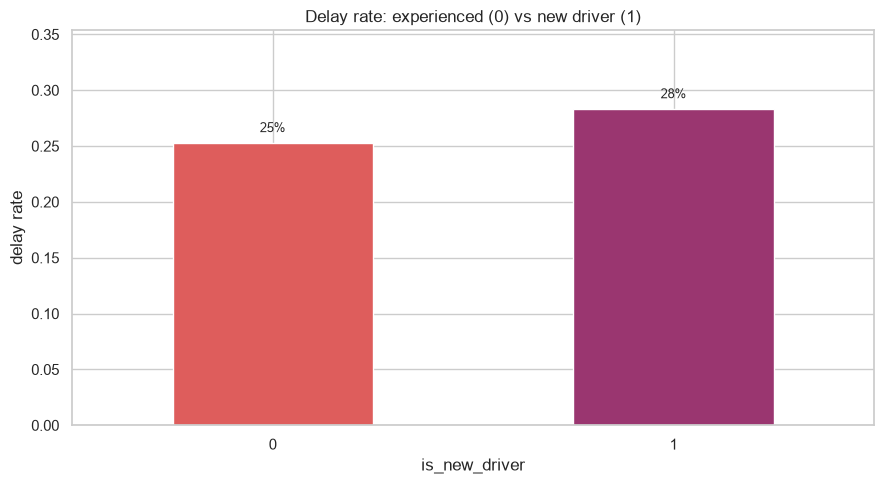

_grp
0    0.252467
1    0.282787
Name: is_delayed, dtype: float64

In [23]:
delay_rate_by(feat, 'is_new_driver', order=[0, 1],
              title='Delay rate: experienced (0) vs new driver (1)')

### 3c · `high_complexity_route` (many stops AND high volume)

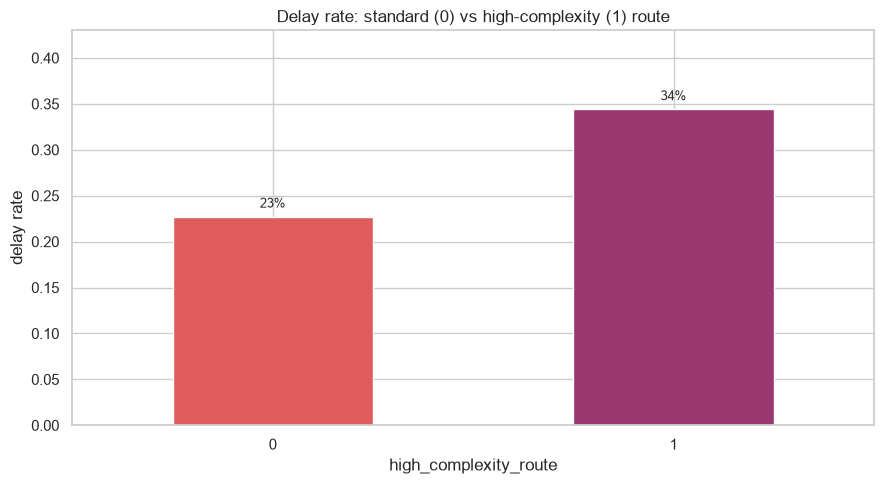

_grp
0    0.226956
1    0.343902
Name: is_delayed, dtype: float64

In [24]:
delay_rate_by(feat, 'high_complexity_route', order=[0, 1],
              title='Delay rate: standard (0) vs high-complexity (1) route')

### 3d · `complexity_index` (stops × traffic)

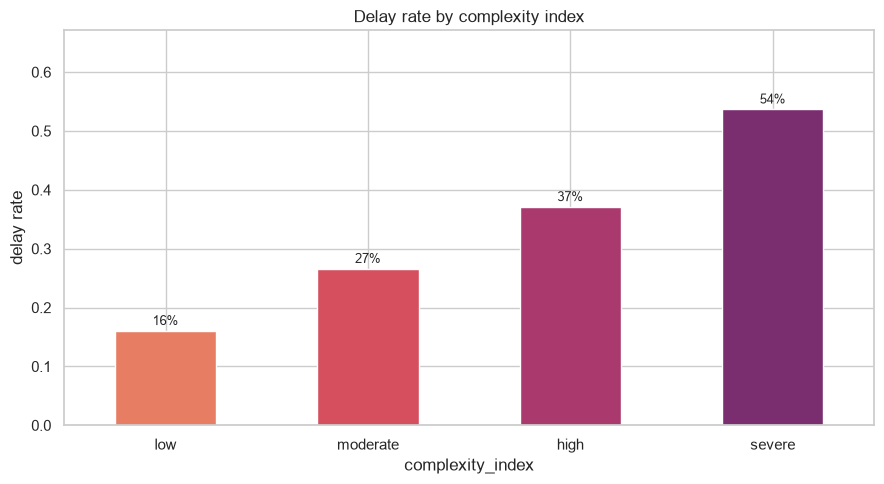

_grp
low         0.160236
moderate    0.265750
high        0.370715
severe      0.536585
Name: is_delayed, dtype: float64

In [25]:
delay_rate_by(feat, 'complexity_index',
              bins=[0, 12, 18, 24, 100],
              labels=['low', 'moderate', 'high', 'severe'],
              title='Delay rate by complexity index')

## 4 · Build the model-ready feature matrix

`build_feature_matrix` returns a fully numeric `X` (raw + engineered + one-hot categoricals)
and the target `y`. It includes an assertion that **no leakage column** ever lands in `X`.


In [26]:
X, y = pp.build_feature_matrix(df)
print(f"X: {X.shape[0]:,} rows x {X.shape[1]} columns")
print(f"y positive (delayed) rate: {y.mean():.1%}")
print("\nNo leakage in X — assertion inside build_feature_matrix passed.")
X.head()

X: 12,000 rows x 47 columns
y positive (delayed) rate: 25.3%

No leakage in X — assertion inside build_feature_matrix passed.


,planned_stops,planned_miles,planned_cases,planned_weight_lbs,planned_duration_min,is_monday,is_month_end,holiday_week_flag,warehouse_load_delay_min,picker_shortage_flag,load_complexity_score,start_delay_min,driver_tenure_days,driver_route_familiarity,driver_avg_delay_rate,retail_stop_pct,restaurant_stop_pct,weather_severity,traffic_index,cases_per_stop,miles_per_stop,weight_per_case,is_new_driver,high_complexity_route,load_delay_over_30,is_high_traffic,restaurant_heavy,complexity_index,window_pressure_ord,start_delay_bucket,dc_DC_CHICAGO,dc_DC_DALLAS,dc_DC_DENVER,dc_DC_NEWARK,dc_DC_PHOENIX,region_Mountain,region_Northeast,region_Southeast,region_Southwest,route_type_suburban,route_type_urban,vehicle_type_tractor_trailer,vehicle_type_van,day_of_week_Mon,day_of_week_Thu,day_of_week_Tue,day_of_week_Wed
0,8,224,362,8172,407,0,0,0,20,0,7.2,20,910,1,0.210,0.75,0.17,0,35,45.250000,28.000000,22.574586,0,0,0,0,0,2.80,2,1,False,False,False,False,True,False,False,False,True,False,False,False,True,False,False,False,True
1,30,33,1167,26842,476,0,0,1,32,1,5.1,13,691,1,0.102,0.66,0.28,1,55,38.900000,1.100000,23.000857,0,1,1,0,0,16.50,0,1,False,False,True,False,False,True,False,False,False,False,True,False,False,False,False,False,True
2,12,177,494,11525,451,0,0,0,19,0,7.8,0,501,0,0.301,0.29,0.54,1,53,41.166667,14.750000,23.329960,0,0,0,0,1,6.36,1,0,False,False,True,False,False,True,False,False,False,False,False,True,False,False,False,False,True
3,30,145,929,19200,574,0,0,0,61,1,2.2,25,138,1,0.130,0.69,0.05,2,64,30.966667,4.833333,20.667384,0,1,1,0,0,19.20,0,1,False,False,False,False,True,False,False,False,True,True,False,False,True,False,False,False,True
4,30,20,1066,26915,463,0,0,0,19,0,5.2,4,1874,1,0.122,0.81,0.00,2,64,35.533333,0.666667,25.248593,0,1,0,0,0,19.20,1,0,False,False,False,False,False,False,False,True,False,False,True,False,True,False,False,False,True


## 5 · Save the processed dataset

We persist the model-ready matrix so the training notebook can load it directly.


In [27]:
os.makedirs('../data/processed', exist_ok=True)
out = pd.concat([X, y.rename('is_delayed')], axis=1)
out.to_csv('../data/processed/model_ready.csv', index=False)
print("Saved ../data/processed/model_ready.csv:", out.shape)

Saved ../data/processed/model_ready.csv: (12000, 48)


## 6 · What's next (Step 4 · Modeling)

We have a clean, leakage-safe, 47-column feature matrix. Next:

1. **Chronological train/test split** (`dg.time_split`) — train on early months, test on late.
2. **Baseline:** Logistic Regression (interpretable, sanity-checks the direction of effects).
3. **Primary:** Gradient Boosting (captures the interactions we saw above).
4. **Evaluate properly:** precision / recall / F1 / ROC-AUC / confusion matrix,
   then a **cost-based threshold**, **probability calibration**, and **SHAP** explanations.
